# Tag Alterations Database Analysis

## 1. Import Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
pd.set_option('display.max_colwidth', None)
print("Libraries imported successfully")

Libraries imported successfully


## 2. Connect to Database and Load Data

In [2]:
#df = pd.read_pickle("../data/full_2025-05.pkl")

### 2.1. Skip if `pickle` used

In [3]:
conn = sqlite3.connect('../data/tags_alterations_teaser_2025-05.db')
df = pd.read_sql_query("SELECT * FROM tag_inconsistencies", conn)

print(f"Loaded {len(df)} tag inconsistencies from database")

Loaded 12177 tag inconsistencies from database


In [19]:
for col in ['old_snap_timestamp', 'old_rev_timestamp', 'new_snap_timestamp', 'new_rev_timestamp', 'min_delta']:
    df[col] = pd.to_datetime(df[col], unit='s', errors='coerce')


In [5]:
df['snap_year'] = df['new_snap_timestamp'].dt.year
df['rev_year'] = df['new_rev_timestamp'].dt.year
df['type'] = df['new_revision'].apply(lambda x: 'Alteration' if pd.notna(x) else 'Deletion')

In [6]:
invalid_snapshots = df[df['old_snap_timestamp'] >= df['new_snap_timestamp']]

print(f"Total inconsistencies: {len(df)}")
print(f"Cases where old_snap_timestamp >= new_snap_timestamp: {len(invalid_snapshots)}")
print(f"Valid snapshot ordering: {len(df) - len(invalid_snapshots)} ({100 * (len(df) - len(invalid_snapshots)) / len(df):.2f}%)")

if len(invalid_snapshots) > 0:
    print("\nSample of invalid cases:")
    print(invalid_snapshots[['origin_url', 'tag_name', 'old_snap_timestamp', 'new_snap_timestamp']].head(10))
else:
    print("\n✓ All old_snapshot timestamps are older than their corresponding new_snapshot timestamps")

Total inconsistencies: 12177
Cases where old_snap_timestamp >= new_snap_timestamp: 0
Valid snapshot ordering: 12177 (100.00%)

✓ All old_snapshot timestamps are older than their corresponding new_snapshot timestamps


In [7]:
df = df.drop(columns=['id'])

In [23]:
df['delta'] = np.where(
    (df['new_snapshot_cpt'] - df['old_snapshot_cpt']) < 2,
    0,
    (df['min_delta'] - df['old_rev_timestamp']).dt.days
)

In [24]:
df.head()

,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type,delta
0,https://github.com/jgraph/drawio-desktop,refs/tags/v13.9.20,swh:1:snp:b2bdb44dc829533fdf455c874a55b4ccc8aefeb5,6,2020-12-12 16:27:28,swh:1:rev:63a85cbd472c8ac02c385a52d64482958a88f261,2020-11-19 09:31:22,swh:1:dir:ba7849805db3a8e9365648e9fe83e15ccf2b4962,swh:1:snp:6472879fb2e6395e97ccdb05156b208556492b4b,7,2021-01-22 04:17:24,NaN,NaT,NaN,2020-12-12 16:27:28,2021,NaN,Deletion,0
1,https://github.com/jgraph/drawio-desktop,refs/tags/v20.6.0,swh:1:snp:c87c57e915ca51e1197c172167470c720386fd06,21,2022-12-06 05:50:42,swh:1:rev:e01c6c173421bfb9b8d407b29904c123fc4ce2d4,2022-12-02 09:36:57,swh:1:dir:792f7e72369dc1c14837523a835a32687eb8348a,swh:1:snp:f679076b5f46b201b922f6276044e293249a955c,22,2022-12-16 12:36:28,NaN,NaT,NaN,2022-12-06 05:50:42,2022,NaN,Deletion,0
2,https://github.com/ruanyf/weekly,refs/tags/issue-178,swh:1:snp:5338ff6be308f9ddc8cc66f89e3f6537b9005196,4,2022-11-05 12:05:46,swh:1:rev:4a446b2381ee98ac822db1c8579011c7c35d9778,2021-10-07 22:15:31,swh:1:dir:6fb8c30d41b6c08bbf91823c29ad1710af6cc593,swh:1:snp:52114ea025de12f134bdc9f349881cf7118087b0,50,2022-11-19 17:55:35,swh:1:rev:a6268cdba47c6c8d648d0987811fddf0f5793e6b,2021-10-07 22:15:31,swh:1:dir:c4c1372bf0b4e7a7ec4c655d352bbf496e587fb8,2022-11-05 12:05:46,2022,2021.0,Alteration,393
3,https://github.com/ruanyf/weekly,refs/tags/issue-178,swh:1:snp:eefad8dab500d0ea65aaa43703f867b204eebaf7,50,2022-11-24 13:58:34,swh:1:rev:a6268cdba47c6c8d648d0987811fddf0f5793e6b,2021-10-07 22:15:31,swh:1:dir:c4c1372bf0b4e7a7ec4c655d352bbf496e587fb8,swh:1:snp:e2042f6e8f77d46c5ae3e7330cd63780b802d605,52,2022-11-30 22:29:00,swh:1:rev:4a446b2381ee98ac822db1c8579011c7c35d9778,2021-10-07 22:15:31,swh:1:dir:6fb8c30d41b6c08bbf91823c29ad1710af6cc593,2022-11-24 13:58:34,2022,2021.0,Alteration,412
4,https://github.com/ruanyf/weekly,refs/tags/issue-213,swh:1:snp:5338ff6be308f9ddc8cc66f89e3f6537b9005196,32,2022-11-05 12:05:46,swh:1:rev:1fa4837b316c3cdfa0893732ab0c111a62472c3c,2022-07-08 00:09:54,swh:1:dir:02793b90b4ec2542628f60658ee57f1ba93cb25e,swh:1:snp:52114ea025de12f134bdc9f349881cf7118087b0,50,2022-11-19 17:55:35,swh:1:rev:5693e62abe63abc3f1b5fb8f84b30f2272c64a7d,2022-07-08 00:09:54,swh:1:dir:8d9066ed5e4b9eb1494ed934901d9012cc5e9a53,2022-11-05 12:05:46,2022,2022.0,Alteration,120


In [9]:
# with open('../data/full_2025-05.pkl', 'wb') as f:
#     pickle.dump(df, f) 

## 3. Explore the DataFrame

In [10]:
print("DataFrame shape:", df.shape)
df.head()

DataFrame shape: (12177, 18)


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type
0,https://github.com/jgraph/drawio-desktop,refs/tags/v13.9.20,swh:1:snp:b2bdb44dc829533fdf455c874a55b4ccc8aefeb5,6,2020-12-12 16:27:28,swh:1:rev:63a85cbd472c8ac02c385a52d64482958a88f261,2020-11-19 09:31:22,swh:1:dir:ba7849805db3a8e9365648e9fe83e15ccf2b4962,swh:1:snp:6472879fb2e6395e97ccdb05156b208556492b4b,7,2021-01-22 04:17:24,NaN,NaT,NaN,1607790448,2021,NaN,Deletion
1,https://github.com/jgraph/drawio-desktop,refs/tags/v20.6.0,swh:1:snp:c87c57e915ca51e1197c172167470c720386fd06,21,2022-12-06 05:50:42,swh:1:rev:e01c6c173421bfb9b8d407b29904c123fc4ce2d4,2022-12-02 09:36:57,swh:1:dir:792f7e72369dc1c14837523a835a32687eb8348a,swh:1:snp:f679076b5f46b201b922f6276044e293249a955c,22,2022-12-16 12:36:28,NaN,NaT,NaN,1670305842,2022,NaN,Deletion
2,https://github.com/ruanyf/weekly,refs/tags/issue-178,swh:1:snp:5338ff6be308f9ddc8cc66f89e3f6537b9005196,4,2022-11-05 12:05:46,swh:1:rev:4a446b2381ee98ac822db1c8579011c7c35d9778,2021-10-07 22:15:31,swh:1:dir:6fb8c30d41b6c08bbf91823c29ad1710af6cc593,swh:1:snp:52114ea025de12f134bdc9f349881cf7118087b0,50,2022-11-19 17:55:35,swh:1:rev:a6268cdba47c6c8d648d0987811fddf0f5793e6b,2021-10-07 22:15:31,swh:1:dir:c4c1372bf0b4e7a7ec4c655d352bbf496e587fb8,1667649946,2022,2021.0,Alteration
3,https://github.com/ruanyf/weekly,refs/tags/issue-178,swh:1:snp:eefad8dab500d0ea65aaa43703f867b204eebaf7,50,2022-11-24 13:58:34,swh:1:rev:a6268cdba47c6c8d648d0987811fddf0f5793e6b,2021-10-07 22:15:31,swh:1:dir:c4c1372bf0b4e7a7ec4c655d352bbf496e587fb8,swh:1:snp:e2042f6e8f77d46c5ae3e7330cd63780b802d605,52,2022-11-30 22:29:00,swh:1:rev:4a446b2381ee98ac822db1c8579011c7c35d9778,2021-10-07 22:15:31,swh:1:dir:6fb8c30d41b6c08bbf91823c29ad1710af6cc593,1669298314,2022,2021.0,Alteration
4,https://github.com/ruanyf/weekly,refs/tags/issue-213,swh:1:snp:5338ff6be308f9ddc8cc66f89e3f6537b9005196,32,2022-11-05 12:05:46,swh:1:rev:1fa4837b316c3cdfa0893732ab0c111a62472c3c,2022-07-08 00:09:54,swh:1:dir:02793b90b4ec2542628f60658ee57f1ba93cb25e,swh:1:snp:52114ea025de12f134bdc9f349881cf7118087b0,50,2022-11-19 17:55:35,swh:1:rev:5693e62abe63abc3f1b5fb8f84b30f2272c64a7d,2022-07-08 00:09:54,swh:1:dir:8d9066ed5e4b9eb1494ed934901d9012cc5e9a53,1667649946,2022,2022.0,Alteration


## 4. Queries

In [11]:
tag_deletions = df[df['new_revision'].isnull()]
tag_alterations = df[df['new_revision'].notnull()]

print(f"Tag Alterations: {len(tag_alterations)}")
print(f"Tag Deletions: {len(tag_deletions)}")
print(f"Total: {len(df)}")

Tag Alterations: 1007
Tag Deletions: 11170
Total: 12177


In [12]:
# Find origins with most tag inconsistencies
origins_with_most_issues = df.groupby('origin_url').size().sort_values(ascending=False)
print("Top 10 origins with most tag inconsistencies:")
origins_with_most_issues.head(10)

Top 10 origins with most tag inconsistencies:


origin_url
https://github.com/ccxt/ccxt                      9174
https://github.com/apache/kafka                   1331
https://github.com/lodash/lodash                   533
https://github.com/rapid7/metasploit-framework     232
https://github.com/ruanyf/weekly                   144
https://github.com/discourse/discourse              97
https://github.com/parcel-bundler/parcel            80
https://github.com/apache/airflow                   64
https://github.com/gatsbyjs/gatsby                  64
https://github.com/expo/expo                        64
dtype: int64

In [13]:
tag_alterations[['origin_url', 'tag_name', 'old_snapshot', 'new_snapshot', 'old_snap_timestamp', 'new_snap_timestamp', 'old_rev_timestamp', 'new_rev_timestamp']].head()

,origin_url,tag_name,old_snapshot,new_snapshot,old_snap_timestamp,new_snap_timestamp,old_rev_timestamp,new_rev_timestamp
2,https://github.com/ruanyf/weekly,refs/tags/issue-178,swh:1:snp:5338ff6be308f9ddc8cc66f89e3f6537b9005196,swh:1:snp:52114ea025de12f134bdc9f349881cf7118087b0,2022-11-05 12:05:46,2022-11-19 17:55:35,2021-10-07 22:15:31,2021-10-07 22:15:31
3,https://github.com/ruanyf/weekly,refs/tags/issue-178,swh:1:snp:eefad8dab500d0ea65aaa43703f867b204eebaf7,swh:1:snp:e2042f6e8f77d46c5ae3e7330cd63780b802d605,2022-11-24 13:58:34,2022-11-30 22:29:00,2021-10-07 22:15:31,2021-10-07 22:15:31
4,https://github.com/ruanyf/weekly,refs/tags/issue-213,swh:1:snp:5338ff6be308f9ddc8cc66f89e3f6537b9005196,swh:1:snp:52114ea025de12f134bdc9f349881cf7118087b0,2022-11-05 12:05:46,2022-11-19 17:55:35,2022-07-08 00:09:54,2022-07-08 00:09:54
5,https://github.com/ruanyf/weekly,refs/tags/issue-213,swh:1:snp:eefad8dab500d0ea65aaa43703f867b204eebaf7,swh:1:snp:e2042f6e8f77d46c5ae3e7330cd63780b802d605,2022-11-24 13:58:34,2022-11-30 22:29:00,2022-07-08 00:09:54,2022-07-08 00:09:54
6,https://github.com/ruanyf/weekly,refs/tags/issue-161,swh:1:snp:5338ff6be308f9ddc8cc66f89e3f6537b9005196,swh:1:snp:52114ea025de12f134bdc9f349881cf7118087b0,2022-11-05 12:05:46,2022-11-19 17:55:35,2021-06-04 01:23:59,2021-06-04 01:23:59


In [14]:
github = df[df['origin_url'].str.contains(r'^https?://[^/]*github\.com', regex=True, na=False)]
gitlab = df[df['origin_url'].str.contains(r'^https?://[^/]*gitlab\.', regex=True, na=False)]
android = df[df['origin_url'].str.contains(r'^https?://android\.googlesource\.com', regex=True, na=False)]
bitbucket = df[df['origin_url'].str.contains(r'^https?://[^/]*bitbucket\.', regex=True, na=False)]
codeberg = df[df['origin_url'].str.contains(r'^https?://[^/]*codeberg\.', regex=True, na=False)]
print(f"Amount of inconsistencies in GitHub: {len(github)}")
print(f"Amount of inconsistencies in GitLab: {len(gitlab)}")
print(f"Amount of inconsistencies in Android: {len(android)}")
print(f"Amount of inconsistencies in BitBucket: {len(bitbucket)}")
print(f"Amount of inconsistencies in Codeberg: {len(codeberg)}")

Amount of inconsistencies in GitHub: 12177
Amount of inconsistencies in GitLab: 0
Amount of inconsistencies in Android: 0
Amount of inconsistencies in BitBucket: 0
Amount of inconsistencies in Codeberg: 0


In [15]:
github_with_most_issues = github.groupby('origin_url').size().sort_values(ascending=False)
gitlab_with_most_issues = gitlab.groupby('origin_url').size().sort_values(ascending=False)
android_with_most_issues = android.groupby('origin_url').size().sort_values(ascending=False)
bitbucket_with_most_issues = bitbucket.groupby('origin_url').size().sort_values(ascending=False)
codeberg_with_most_issues = codeberg.groupby('origin_url').size().sort_values(ascending=False)
print(f"GitHub most inconsistencies:\n", github_with_most_issues.head(2))
print(f"Gitlab most inconsistencies:\n", gitlab_with_most_issues.head(2))
print(f"Android most inconsistencies:\n", android_with_most_issues.head(2))
print(f"Bitbucket most inconsistencies:\n", bitbucket_with_most_issues.head(2))
print(f"Codeberg most inconsistencies:\n", codeberg_with_most_issues.head(2))

GitHub most inconsistencies:
 origin_url
https://github.com/ccxt/ccxt       9174
https://github.com/apache/kafka    1331
dtype: int64
Gitlab most inconsistencies:
 Series([], dtype: int64)
Android most inconsistencies:
 Series([], dtype: int64)
Bitbucket most inconsistencies:
 Series([], dtype: int64)
Codeberg most inconsistencies:
 Series([], dtype: int64)


In [16]:
others = df[df['origin_url'].apply(lambda x: 'github' not in x and 'gitlab' not in x and 'android.googlesource' not in x)]
if len(others) > 0:
    others.sample(10)

In [17]:
# Inconsistencies where new_root_dir equals old_root_dir
same_root_dir = df[df['new_root_dir'] == df['old_root_dir']]
print(f"Inconsistencies where new_root_dir = old_root_dir: {len(same_root_dir)}")
same_root_dir.head()

Inconsistencies where new_root_dir = old_root_dir: 5


,origin_url,tag_name,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,type
11337,https://github.com/dbeaver/dbeaver,refs/tags/4.0.2,swh:1:snp:7455482d6b340e721eb425b77d34e421265c3667,0,2020-12-12 14:25:25,swh:1:rev:0537e832411051c54cae4dadc798cd5f64a8c5bb,2017-03-01 19:41:13,swh:1:dir:3fbb3170b4158da7b20ecae26abef91e7ad8ba61,swh:1:snp:a02a8f0bd00271f4df7bd4c33e6b1c7d40fa3e13,27,2021-06-01 16:20:39,swh:1:rev:b3ea2e50c60c9625863cdebea0ed75377c41ad63,2017-03-01 19:41:13,swh:1:dir:3fbb3170b4158da7b20ecae26abef91e7ad8ba61,1607783125,2021,2017.0,Alteration
11482,https://github.com/lodash/lodash,refs/tags/3.0.1-npm-packages,swh:1:snp:cc65691b62b5c99eed3fbd7ebfb14090aafe9785,7,2016-08-13 13:32:04,swh:1:rev:0c478b1203e86ff93681e3ae664e8cc066459083,2016-07-29 16:53:04,swh:1:dir:bcf9774b3f01d8f0da169fd1b2c852363bcfb712,swh:1:snp:966c3d5901b7f4ba15eda0b5c37237a215db4560,8,2016-08-17 02:38:57,swh:1:rev:60b8329a73b486d5361cc74633efb09d15c84823,2016-08-12 20:45:37,swh:1:dir:bcf9774b3f01d8f0da169fd1b2c852363bcfb712,1471095124,2016,2016.0,Alteration
11609,https://github.com/lodash/lodash,refs/tags/3.0.0-npm-packages,swh:1:snp:cc65691b62b5c99eed3fbd7ebfb14090aafe9785,7,2016-08-13 13:32:04,swh:1:rev:cb31c71925ca0583719f88368662f5a7291c06c7,2016-07-29 16:53:04,swh:1:dir:8f69189f4424c2c3abb615dd3fb2364fdc5fac3c,swh:1:snp:966c3d5901b7f4ba15eda0b5c37237a215db4560,8,2016-08-17 02:38:57,swh:1:rev:bb53dde973082cbf549e3daf7e7780da483c8176,2016-08-12 20:45:37,swh:1:dir:8f69189f4424c2c3abb615dd3fb2364fdc5fac3c,1471095124,2016,2016.0,Alteration
11960,https://github.com/facebookresearch/faiss,refs/tags/v1.7.3,swh:1:snp:98e0af0ec7bbed9b615d3b2da997f3d95e2afbcf,34,2022-11-25 12:44:37,swh:1:rev:be018dd4e0210a28ccfa6530df85aa0703c0ec58,2022-11-08 11:14:13,swh:1:dir:dc629be9c6b1b6f915f93ad72383b60697b66d87,swh:1:snp:94f14f77b7c8521c7baa36c0e407a9a64a462b00,35,2022-12-04 05:45:28,swh:1:rev:19f7696deedc93615c3ee0ff4de22284b53e0243,2022-11-08 11:44:51,swh:1:dir:dc629be9c6b1b6f915f93ad72383b60697b66d87,1669380277,2022,2022.0,Alteration
12001,https://github.com/pandas-dev/pandas,refs/tags/v2.2.0dev0,swh:1:snp:019c5eeb8f59bc80fc792828133227db6f9ccea8,134,2023-08-28 21:30:27,swh:1:rev:aa6db65560591f166fda36b448f0defe5c9c7112,2023-08-11 16:27:51,swh:1:dir:20268655466586dc38de33e58ee86a30cfdffd74,swh:1:snp:139a0760cbabd3643a8ad280746ad3c0c48b10de,139,2023-08-31 21:56:51,swh:1:rev:49ca01ba9023b677f2b2d1c42e99f45595258b74,2023-08-11 16:28:57,swh:1:dir:20268655466586dc38de33e58ee86a30cfdffd74,1693258227,2023,2023.0,Alteration


## 5. Figures

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_sorted = df.sort_values('new_snap_timestamp')
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

df['year'] = df['new_snap_timestamp'].dt.year
inconsistencies_by_year = df.groupby('year').size()

ax1.bar(inconsistencies_by_year.index, inconsistencies_by_year.values, width=0.8, alpha=0.7, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Inconsistencies', fontsize=12)
ax1.set_title('Tag Inconsistencies Over Time (Yearly Count - Including Alterations & Deletions)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(inconsistencies_by_year.index)

ax2.plot(df_sorted['new_snap_timestamp'], 
         df_sorted['cumulative_count'], 
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Inconsistencies', fontsize=12)
ax2.set_title('Cumulative Tag Inconsistencies Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Total tag inconsistencies plotted: {len(df)}")
print(f"  - Tag Alterations: {len(tag_alterations)}")
print(f"  - Tag Deletions: {len(tag_deletions)}")
print(f"Date range: {df['new_snap_timestamp'].min()} to {df['new_snap_timestamp'].max()}")

ModuleNotFoundError: No module named 'matplotlib'

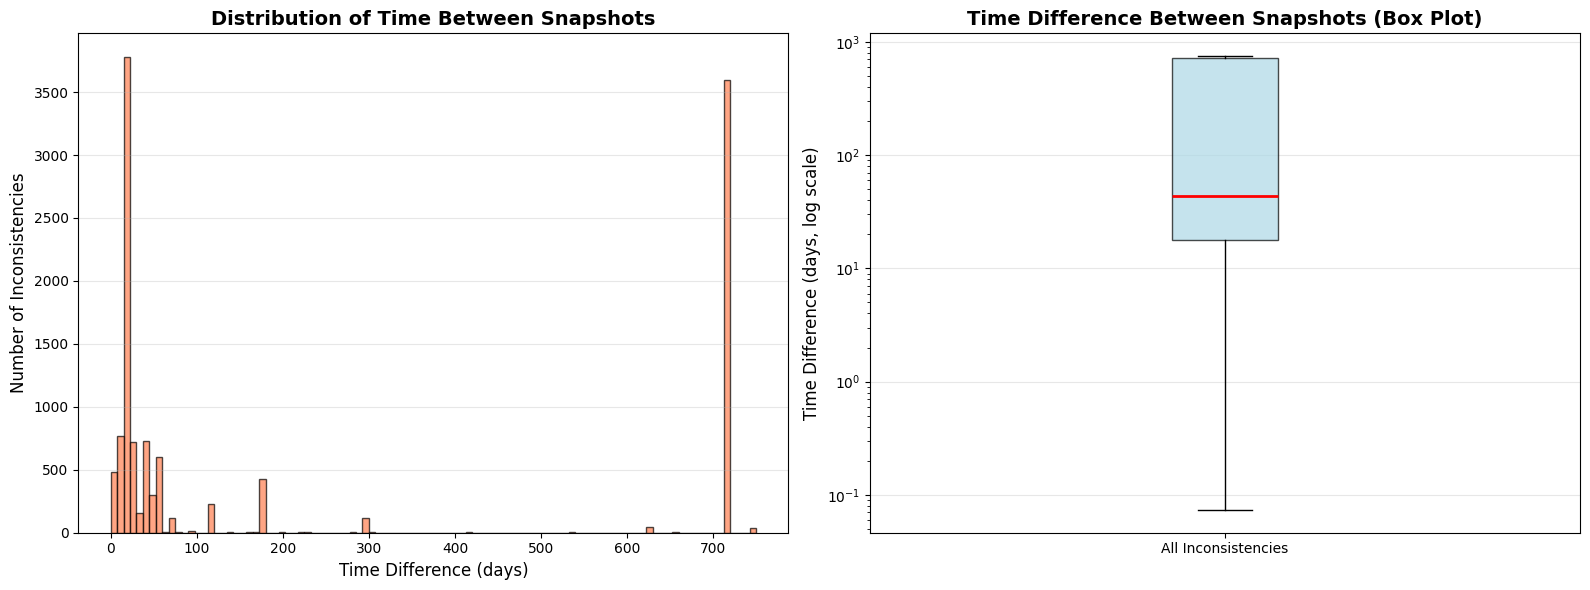

Time difference statistics:
  Mean: 245.47 days
  Median: 43.69 days
  Min: 0.07 days
  Max: 749.65 days
  Std: 313.97 days


In [ ]:
df['time_diff_days'] = (df['new_snap_timestamp'] - df['old_snap_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_diffs_filtered = df['time_diff_days'].dropna()
ax1.hist(time_diffs_filtered, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Time Difference (days)', fontsize=12)
ax1.set_ylabel('Number of Inconsistencies', fontsize=12)
ax1.set_title('Distribution of Time Between Snapshots', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([time_diffs_filtered[time_diffs_filtered > 0]], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Time Difference (days, log scale)', fontsize=12)
ax2.set_title('Time Difference Between Snapshots (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['All Inconsistencies'])

plt.tight_layout()
plt.show()

print(f"Time difference statistics:")
print(f"  Mean: {time_diffs_filtered.mean():.2f} days")
print(f"  Median: {time_diffs_filtered.median():.2f} days")
print(f"  Min: {time_diffs_filtered.min():.2f} days")
print(f"  Max: {time_diffs_filtered.max():.2f} days")
print(f"  Std: {time_diffs_filtered.std():.2f} days")

/tmp/ipykernel_1851250/665565989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tag_alterations['rev_time_diff_days'] = (tag_alterations['new_rev_timestamp'] - tag_alterations['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)


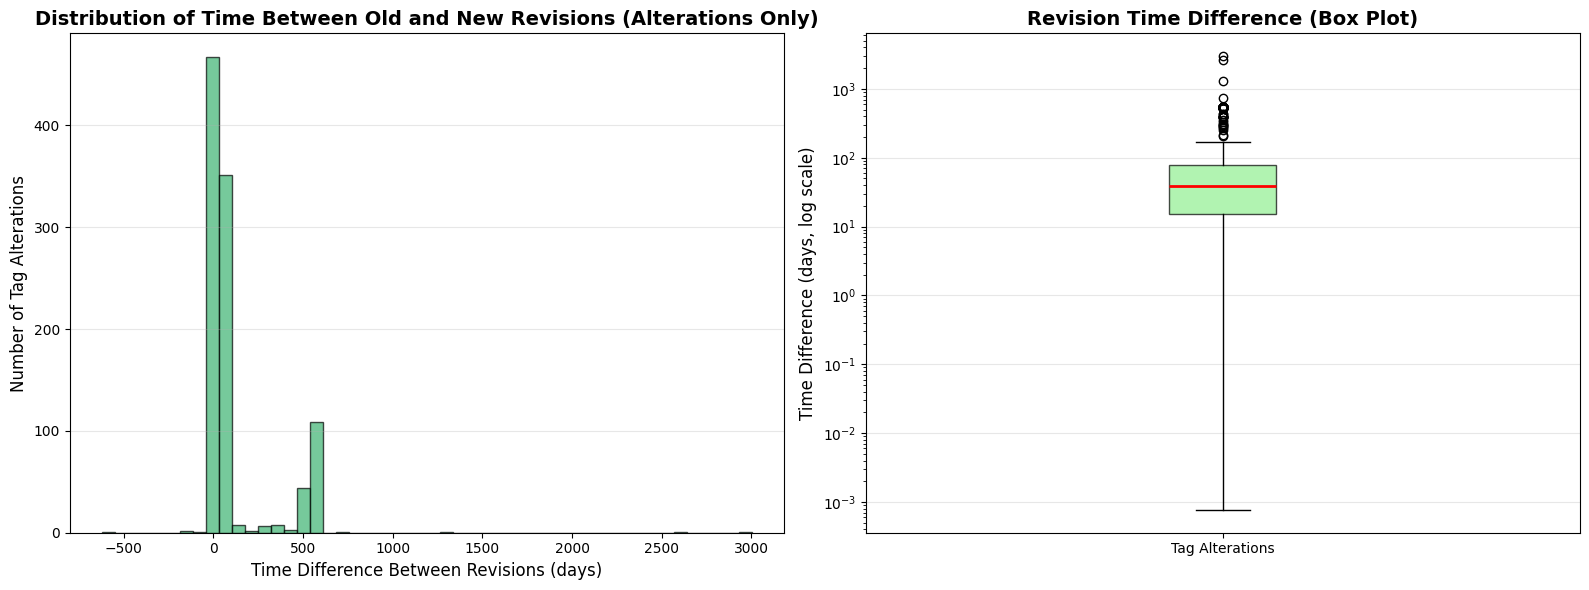

Revision time difference statistics (for 1007 alterations):
  Mean: 118.07 days
  Median: 31.92 days
  Min: -620.97 days
  Max: 3001.17 days
  Std: 227.14 days
  Negative values (new revision older than old): 18


In [ ]:
tag_alterations['rev_time_diff_days'] = (tag_alterations['new_rev_timestamp'] - tag_alterations['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rev_time_diffs = tag_alterations['rev_time_diff_days'].dropna()
ax1.hist(rev_time_diffs, bins=50, alpha=0.7, color='mediumseagreen', edgecolor='black')
ax1.set_xlabel('Time Difference Between Revisions (days)', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Distribution of Time Between Old and New Revisions (Alterations Only)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

positive_rev_diffs = rev_time_diffs[rev_time_diffs > 0]
if len(positive_rev_diffs) > 0:
    ax2.boxplot([positive_rev_diffs], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Time Difference (days, log scale)', fontsize=12)
    ax2.set_title('Revision Time Difference (Box Plot)', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(['Tag Alterations'])

plt.tight_layout()
plt.show()

print(f"Revision time difference statistics (for {len(tag_alterations)} alterations):")
print(f"  Mean: {rev_time_diffs.mean():.2f} days")
print(f"  Median: {rev_time_diffs.median():.2f} days")
print(f"  Min: {rev_time_diffs.min():.2f} days")
print(f"  Max: {rev_time_diffs.max():.2f} days")
print(f"  Std: {rev_time_diffs.std():.2f} days")
print(f"  Negative values (new revision older than old): {len(rev_time_diffs[rev_time_diffs < 0])}")

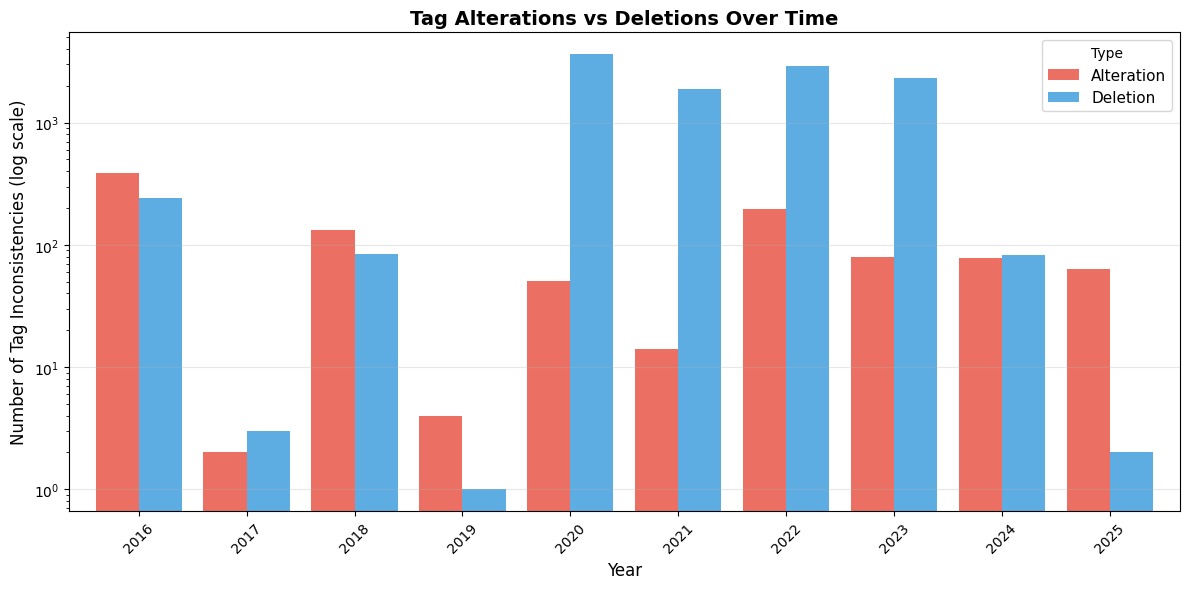


Yearly breakdown:
type  Alteration  Deletion
year                      
2016         389       242
2017           2         3
2018         131        84
2019           4         1
2020          51      3640
2021          14      1868
2022         195      2930
2023          80      2318
2024          78        82
2025          63         2

Total Alterations: 1007
Total Deletions: 11170


In [ ]:
inconsistencies_by_year_type = df.groupby(['year', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

inconsistencies_by_year_type.plot(kind='bar', ax=ax, 
                                   color=['#e74c3c', '#3498db'], alpha=0.8, width=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Tag Inconsistencies (log scale)', fontsize=12)
ax.set_title('Tag Alterations vs Deletions Over Time', fontsize=14, fontweight='bold')
ax.legend(title='Type', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')  # Log scale to see alterations better

plt.tight_layout()
plt.show()

print("\nYearly breakdown:")
print(inconsistencies_by_year_type)
print(f"\nTotal Alterations: {inconsistencies_by_year_type['Alteration'].sum()}")
print(f"Total Deletions: {inconsistencies_by_year_type['Deletion'].sum()}")

## Last. Close Database Connection

In [ ]:
conn.close()
print("Database connection closed")

Database connection closed
